In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv

In [2]:
# Define grid parameters
spacing = 80  # Distance between nearest neighbors
maxradius = 800

In [3]:
dx = spacing  # Horizontal spacing
dy = np.sqrt(3) / 2 * spacing  # Vertical spacing (~69.28m)

# Define area boundaries
x_min, x_max = -maxradius, maxradius
y_min, y_max = -maxradius, maxradius

# Generate hexagonal grid points
grid_points = []
y = y_min
row = 0  # Track row index for offsetting

while y <= y_max:
    x_offset = (dx / 2) * (row % 2)  # Offset every second row
    x = x_min + x_offset
    
    while x <= x_max:
        grid_points.append((x, y))
        x += dx  # Move right by dx

    y += dy  # Move up by dy
    row += 1  # Increase row index

grid_points = np.array(grid_points)  # Convert list to NumPy array

In [4]:
def remove_exceeding_points(points, max_distance):
    # Function to calculate the distance from the origin (0, 0)
    def distance_from_origin(point):
        return np.sqrt(point[0]**2 + point[1]**2)
    
    # Filter points that are within the max_distance from the origin
    filtered_points = [point for point in points if distance_from_origin(point) <= max_distance]
    
    return np.array(filtered_points)

In [5]:
grid_points=remove_exceeding_points(grid_points,0.975*maxradius) #cut to a circular acceptance, 0.975 manually tuned to give best result

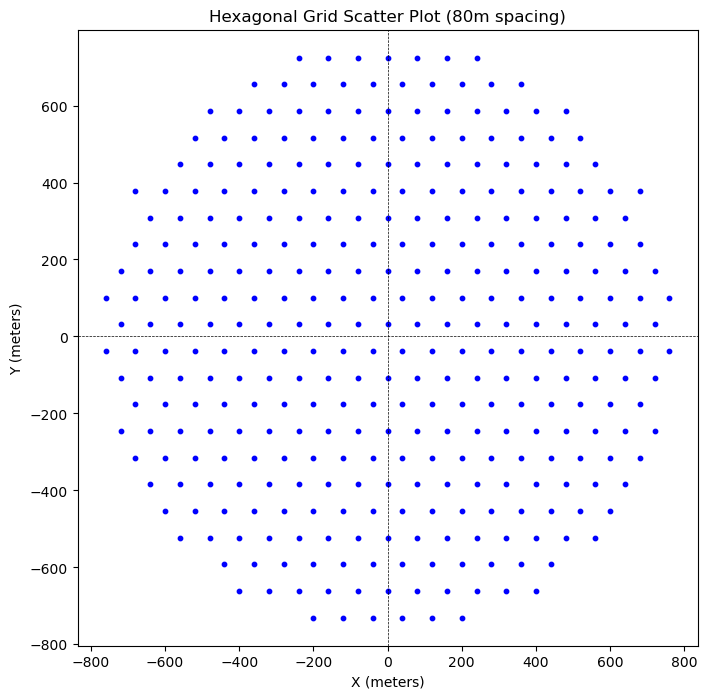

In [6]:
# Plot the hexagonal grid
plt.figure(figsize=(8, 8))
plt.scatter(grid_points[:, 0], grid_points[:, 1], color="blue", s=10, label="Hexagonal Grid Points")
# Labels and formatting
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Hexagonal Grid Scatter Plot ({spacing}m spacing)")
plt.axhline(0, color="black", linestyle="--", linewidth=0.5)  # X-axis
plt.axvline(0, color="black", linestyle="--", linewidth=0.5)  # Y-axis

#plt.savefig("dots.png")

plt.show()


In [8]:
np.save('340grid_xy.npy', grid_points)

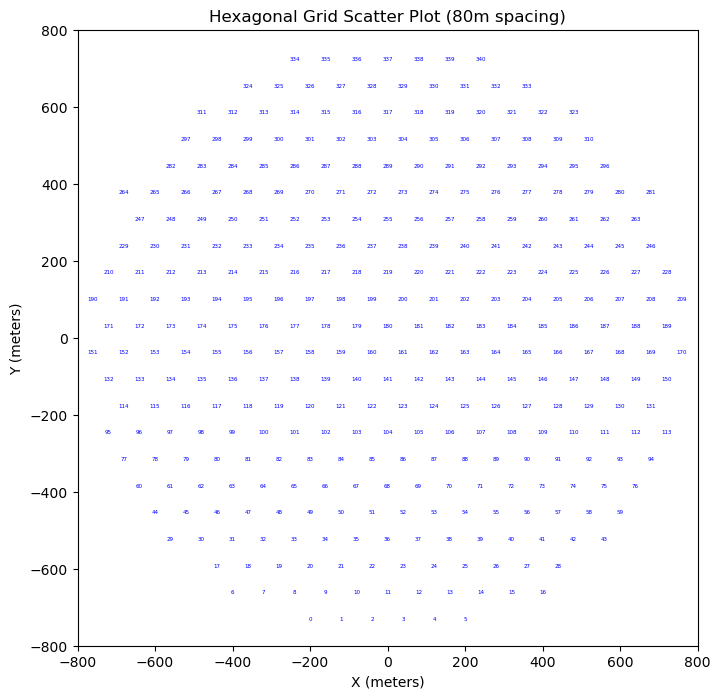

In [7]:
plt.figure(figsize=(8, 8))
for i, point in enumerate(grid_points):
    plt.text(point[0], point[1], str(i), color="blue", fontsize=4, ha='center', va='center')

# Labels and formatting
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Hexagonal Grid Scatter Plot ({spacing}m spacing)")

plt.xlim(-maxradius,maxradius)
plt.ylim(-maxradius,maxradius)

#plt.savefig("numbered.png")

plt.show()

In [26]:
# Build an annulus-like selection on the generated grid
inner_radius = 195.0
outer_radius = 420.0
target_count = 75

radii = np.hypot(grid_points[:, 0], grid_points[:, 1])
ring_mid = 0.5 * (inner_radius + outer_radius)
thetas = np.mod(np.arctan2(grid_points[:, 1], grid_points[:, 0]), 2.0 * np.pi)

# Radial violation is 0 inside the annulus and grows with distance outside
radial_violation = np.where(
    radii < inner_radius,
    inner_radius - radii,
    np.where(radii > outer_radius, radii - outer_radius, 0.0),
)

# Start from points in the exact annulus and expand minimally if needed
exact_candidate_indices = np.where(radial_violation == 0.0)[0]
if len(exact_candidate_indices) >= target_count:
    candidate_indices = exact_candidate_indices
else:
    # Include nearest out-of-band points so exact count is feasible
    sorted_all = np.argsort(radial_violation)
    candidate_indices = sorted_all[: max(target_count * 2, len(exact_candidate_indices))]

# Choose points with near-uniform angular coverage for symmetry
target_angles = np.linspace(0.0, 2.0 * np.pi, target_count, endpoint=False)
remaining = set(candidate_indices.tolist())
selected = []

for t in target_angles:
    if not remaining:
        break
    rem = np.array(sorted(remaining), dtype=int)
    d_theta = np.abs(thetas[rem] - t)
    d_theta = np.minimum(d_theta, 2.0 * np.pi - d_theta)
    d_radius = np.abs(radii[rem] - ring_mid) / (outer_radius - inner_radius)
    d_violation = radial_violation[rem] / max(1.0, spacing)

    # Prioritize angle symmetry, then annulus adherence, then radial balance
    score = d_theta + 0.20 * d_violation + 0.10 * d_radius
    best_idx = rem[int(np.argmin(score))]

    selected.append(int(best_idx))
    remaining.remove(int(best_idx))

# If any slots remain, fill by smallest radial violation
if len(selected) < target_count:
    unused = np.setdiff1d(np.arange(len(grid_points)), np.array(selected, dtype=int), assume_unique=False)
    fill_order = unused[np.argsort(radial_violation[unused])]
    needed = target_count - len(selected)
    selected.extend(fill_order[:needed].astype(int).tolist())

highlight_indices = np.array(sorted(set(selected)), dtype=int)

# Ensure exact target_count after de-duplication edge cases
if len(highlight_indices) > target_count:
    ranked = highlight_indices[np.argsort(radial_violation[highlight_indices])]
    highlight_indices = np.array(sorted(ranked[:target_count]), dtype=int)
elif len(highlight_indices) < target_count:
    unused = np.setdiff1d(np.arange(len(grid_points)), highlight_indices, assume_unique=False)
    fill_order = unused[np.argsort(radial_violation[unused])]
    needed = target_count - len(highlight_indices)
    highlight_indices = np.array(
        sorted(np.concatenate([highlight_indices, fill_order[:needed].astype(int)])), dtype=int
    )

if len(highlight_indices) != target_count:
    raise RuntimeError(f"Selected {len(highlight_indices)} points, expected {target_count}.")

# Spacing diagnostics from nearest-neighbor distances inside the selection
selected_points = grid_points[highlight_indices]
deltas = selected_points[:, None, :] - selected_points[None, :, :]
pairwise_dist = np.sqrt(np.sum(deltas**2, axis=2))
np.fill_diagonal(pairwise_dist, np.inf)
nearest_neighbor_dist = np.min(pairwise_dist, axis=1)

# Symmetry and annulus diagnostics
centroid = selected_points.mean(axis=0)
inside_exact_annulus = np.sum(radial_violation[highlight_indices] == 0.0)
max_violation = radial_violation[highlight_indices].max()

print(f"Selected points: {len(highlight_indices)}")
print(f"Target annulus: inner={inner_radius:.1f} m, outer={outer_radius:.1f} m")
print(f"Points inside exact annulus: {inside_exact_annulus}/{target_count}")
print(f"Max radial violation for selected points: {max_violation:.2f} m")
print(f"Average nearest-neighbor spacing: {nearest_neighbor_dist.mean():.2f} m")
print(f"Minimum nearest-neighbor spacing: {nearest_neighbor_dist.min():.2f} m")
print(f"Selection centroid: x={centroid[0]:.2f} m, y={centroid[1]:.2f} m")

Selected points: 75
Target annulus: inner=195.0 m, outer=420.0 m
Points inside exact annulus: 75/75
Max radial violation for selected points: 0.00 m
Average nearest-neighbor spacing: 80.00 m
Minimum nearest-neighbor spacing: 80.00 m
Selection centroid: x=-0.53 m, y=-6.49 m


In [ ]:
highlight_indices = [160, 161, 162, 180, 181, 179, 199, 200, 141, 142] + [252, 253, 254, 269, 270, 271, 272, 286, 287, 288] +\
                    [257, 258, 259, 274, 275, 276, 277, 291, 292, 293] + [146, 147, 165, 166, 167, 184, 185, 186, 204, 205] +\
                    [ 53,  54,  69,  70,  71,  87,  88,  89, 106, 107] + [ 49,  50,  65,  66,  67,  82,  83,  84, 101, 102] +\
                    [135, 136, 154, 155, 156, 174, 175, 176, 194, 195]

In [9]:
highlight_indices = [
    83, 84, 85, 86,
    101, 102, 103, 104, 105, 106, 107,
    118, 119, 120, 121, 122, 123, 124, 125,
    133, 134, 135, 136, 137, 138, 139,
    152, 153, 154, 155, 156, 157, 158,
    176, 177, 178, 179, 180, 181, 183, 184,
    196, 197, 198, 199, 200, 201, 202, 203,
    215, 216, 217, 218, 219, 221, 222,
    234, 235, 236, 237, 238, 239,
    252, 253, 254, 255, 256
]

In [ ]:
for geom_name in ['160_geom', '102_geom']:
    highlight_indices = np.unique(np.loadtxt(f"{geom_name}.csv", delimiter=",", dtype=int))
    np.save(f"{geom_name}_xy.npy", grid_points[highlight_indices])

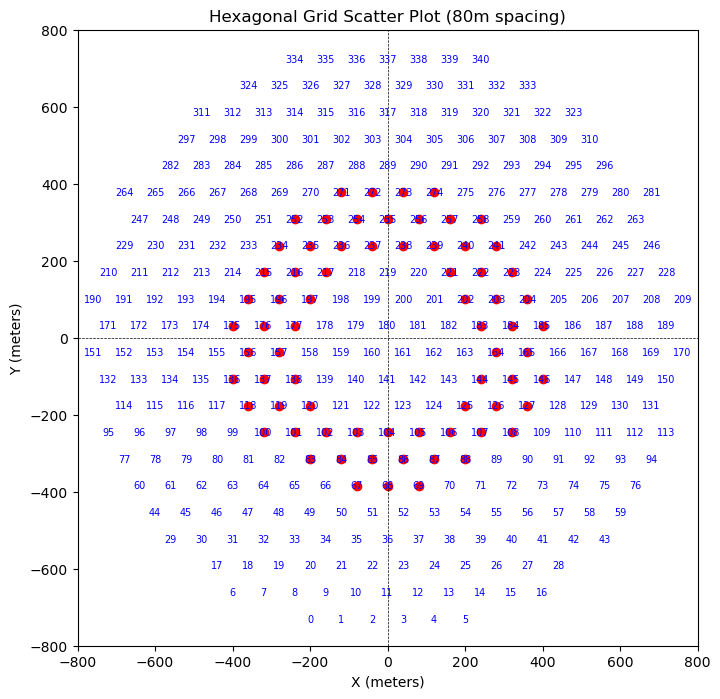

In [34]:
# Plot the hexagonal grid
plt.figure(figsize=(8, 8))
for i, point in enumerate(grid_points):
    plt.text(point[0], point[1], str(i), color="blue", fontsize=7, ha='center', va='center')

plt.scatter(grid_points[highlight_indices, 0], grid_points[highlight_indices, 1], color='red')

# Labels and formatting
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title(f"Hexagonal Grid Scatter Plot ({spacing}m spacing)")
plt.axhline(0, color="black", linestyle="--", linewidth=0.5)  # X-axis
plt.axvline(0, color="black", linestyle="--", linewidth=0.5)  # Y-axis

plt.xlim(-maxradius,maxradius)
plt.ylim(-maxradius,maxradius)

# Show the plot
plt.show()

In [33]:
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 121))
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 124))


In [21]:
highlight_indices = np.append(highlight_indices, [288, 289, 290]) 

In [27]:
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 68))
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 118))
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 108))
highlight_indices = np.append(highlight_indices, [185,175, 223]) 

In [32]:
len(highlight_indices)

73

In [35]:
np.save('donut2_xy.npy', grid_points[highlight_indices])

In [ ]:
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 220))
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 182))
highlight_indices = np.append(highlight_indices, [274,88])
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 68))
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 118))
highlight_indices = np.delete(highlight_indices, np.where(highlight_indices == 108))
highlight_indices = np.append(highlight_indices, [185,175, 223])   

In [36]:
#wrtite to file
csv_grid= "donut2.csv"
with open(csv_grid, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(highlight_indices)